In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import ltn
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

In [4]:
base_model = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B" 

"""
alternative fine tuned version:
model_id = "abhi9ab/DeepSeek-R1-Distill-Llama-8B-finance-v1"
"""

tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    base_model,
    trust_remote_code=True,
    dtype=torch.bfloat16,
    device_map="auto"
)

# Make my own fine-tuned Lora-Adapter
# model = PeftModel.from_pretrained(model, "./your-trained-lora-adapter")

model = model.eval()
print("model loaded!")

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

model loaded!


In [5]:
test_headlines = [
    "NVIDIA beats Q4 earnings expectations but warns of supply chain constraints in 2026."
]

In [6]:
for headline in test_headlines:
    prompt = f"<｜begin of sentence｜><｜User｜>Analyze the market sentiment of this news: {headline}<｜Assistant｜><｜thought｜>"
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=1024,
            temperature=0.1,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id
        )
    
    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    clean_output = full_output.replace('Ġ', ' ').replace('Ċ', '\n').replace('pre', '')
    
    print(f"\nFINANCIAL ANALYSIS FOR: {headline}")
    print("-" * 50)
    
    if "Result" in clean_output:
        parts = clean_output.split("Result")
        print(f"REASONING: {parts[0].strip()}")
        print(f"FINAL SENTIMENT: Result {parts[1].strip()}")
    else:
        print(clean_output)
    
    print("="*50)


FINANCIAL ANALYSIS FOR: NVIDIA beats Q4 earnings expectations but warns of supply chain constraints in 2026.
--------------------------------------------------
<beginofsentence><｜User｜>Analyzethemarketsentimentofthisnews:NVIDIAbeatsQ4earningsexpectationsbutwarnsofsupplychainconstraintsin2026.<｜Assistant｜><thought>Alright, so I'm trying to figure out how to analyze the market sentiment of this news: "NVIDIA beats Q4 earnings expectations but warns of supply chain constraints in 20-26." Hmm, okay, let's break this down step by step.

First, I know that NVIDIA is a big company in the tech industry, especially in graphics cards and AI. Their earnings reports can really impact their stock price and investor sentiment. So, the news says they've beaten their Q4 earnings expectations. That sounds positive. Beating expectations usually means the company did better than what analysts were dicting, which is a good sign. Investors like that because it means the company is performing well.

But th

In [7]:
for headline in test_headlines:
    prompt = f"""
        You are a financial sentiment classifier.
        
        Analyze the headline and respond in EXACTLY this format:
        
        Sentiment: [Bullish, Bearish, or Neutral]
        Confidence: [number between 0 and 1]
        
        Rules:
        - Do NOT explain your reasoning
        - Output ONLY the two lines above
        - Be decisive
        
        Headline: {headline}
        """
            
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=1024,
            temperature=0.1,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id
        )
    
    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    clean_output = full_output.replace('Ġ', ' ').replace('Ċ', '\n').replace('pre', '')
    
    print(f"\nFINANCIAL ANALYSIS FOR: {headline}")
    print("-" * 50)
    
    if "Result" in clean_output:
        parts = clean_output.split("Result")
        print(f"REASONING: {parts[0].strip()}")
        print(f"FINAL SENTIMENT: Result {parts[1].strip()}")
    else:
        print(clean_output)
    
    print("="*50)


FINANCIAL ANALYSIS FOR: NVIDIA beats Q4 earnings expectations but warns of supply chain constraints in 2026.
--------------------------------------------------
Youareafinancialsentimentclassifier.AnalyzetheheadlineandrespondinEXACTLYthisformat:Sentiment:[Bullish,Bearish,orNeutral]Confidence:[numberbetween0and1]Rules:-DoNOTexplainyourreasoning-OutputONLYthetwolinesabove-BedecisiveHeadline:NVIDIAbeatsQ4earningsexpectationsbutwarnsofsupplychainconstraintsin2026. NVIDIA'sQ4earningsexceedexpectations,buttheyalsohighlightedsupplychainconstraintsfor2026. So, the headline is about NVIDIA beating earnings expectations but also warning about supply chain constraints in 2026. Sentiment: Bullish. Confidence: 0.85. NVIDIA's strong earnings and guidance suggest the company is performing well, which is positive for investors. However, the mention of supply chain issues in the future could be a concern. Overall, the sentiment is bullish as the immediate results are strong, outweighing the future conc

In [8]:
"""
deepseek model outputs a (batch_size, 4096) shaped tensor, which is fed into the neurosymbolic head

this tensor is a dense numerical vector representing the 'meaning' of the news headline.
"""

sentiment_head = torch.nn.Sequential(
    torch.nn.Linear(4096, 512),
    torch.nn.ReLU(),
    torch.nn.Linear(512, 1), 
    torch.nn.Sigmoid()
).to("cuda").to(torch.bfloat16)


class MaterialSentimentPredicate(torch.nn.Module):
    def forward(self, sentiment_output, magnitude):
        # if magnitude < 0.5, logic forces result to 0.5 (Neutral)
        is_material = (magnitude > 0.5).float()
        return sentiment_output * is_material + (0.5 * (1.0 - is_material))

is_bullish = ltn.Predicate(MaterialSentimentPredicate())


# freeze deepseek LLM weights
model.eval()
for param in model.parameters():
    param.requires_grad = False

# optimise just the head (neurosymbolic part)
optimizer = torch.optim.AdamW([
    {'params': sentiment_head.parameters(), 'lr': 1e-4},
], lr=1e-4)


# --- The Neurosymbolic Inference & Training Loop ---

def run_step(headline, magnitude_val, label_val):
    optimizer.zero_grad()
    
    # A. Neural Perception (DeepSeek)
    inputs = tokenizer(headline, return_tensors="pt").to("cuda")
    outputs = model(**inputs, output_hidden_states=True)
    
    # Get the embedding of the last token (the "thought" representation)
    # Shape: [1, 4096]
    last_hidden_state = outputs.hidden_states[-1][:, -1, :]
    
    # B. Generate Sentiment via Head
    raw_sentiment = sentiment_head(last_hidden_state)
    
    # C. Wrap in LTN (The Symbolic Bridge)
    s_var = ltn.Variable("sentiment", raw_sentiment)
    m_var = ltn.Variable("magnitude", torch.tensor([[magnitude_val]]).to("cuda").to(torch.bfloat16))
    
    # D. Logical Reasoning
    # This calls your MaterialSentimentPredicate
    prediction = is_bullish(s_var, m_var)
    
    # E. Calculate Loss based on the Logical Outcome
    target = torch.tensor([[label_val]]).to("cuda").to(torch.bfloat16)
    loss = torch.mean((prediction.value - target)**2)
    
    loss.backward()
    optimizer.step()
    return loss.item(), raw_sentiment.item(), prediction.value.item()

# Example Test
loss, neural_gut, final_dec = run_step("Market crashes as inflation spikes", 0.9, 0.0)
print(f"Neural Output: {neural_gut:.4f} | Logical Result: {final_dec:.4f}")

Neural Output: 0.4746 | Logical Result: 0.4746


In [12]:
test_scenarios = [
    # (Headline, Magnitude, Label, Scenario Name)
    ("The company reported a slight increase in office supply efficiency.", 0.1, 0.5, "Immaterial / Low Magnitude"),
    ("BREAKING: CEO arrested as company stock plummets 50% in pre-market trading.", 0.95, 0.0, "Material / Strong Bearish"),
    ("Federal Reserve announces surprise 50bps rate cut to stimulate growth.", 0.9, 1.0, "Material / Strong Bullish"),
    ("A local branch changed its weekend closing time by fifteen minutes.", 0.05, 0.5, "Noise / Near-Zero Magnitude")
]

print(f"{'Scenario':<30} | {'Neural Gut':<12} | {'Final Logic':<12} | {'Status'}")
print("-" * 80)

for headline, mag, label, name in test_scenarios:
    loss, neural_gut, final_dec = run_step(headline, mag, label)
    
    is_neutralized = "Forced Neutral" if (mag <= 0.5 and abs(final_dec - 0.5) < 1e-3) else "Neural Led"
    
    print(f"{name:<30} | {neural_gut:.4f}     | {final_dec:.4f}      | {is_neutralized}")

Scenario                       | Neural Gut   | Final Logic  | Status
--------------------------------------------------------------------------------
Immaterial / Low Magnitude     | 0.1836     | 0.5000      | Forced Neutral
Material / Strong Bearish      | 0.0071     | 0.0071      | Neural Led
Material / Strong Bullish      | 0.7383     | 0.7383      | Neural Led
Noise / Near-Zero Magnitude    | 0.2451     | 0.5000      | Forced Neutral


In [15]:
import os
import glob
import pandas as pd
from huggingface_hub import snapshot_download

REPO_ID = "cookekieran/alphavantage-market-news"

print("📡 Pulling downstream snapshot from private HF repo structure...")

try:
    # This downloads the directory structure seamlessly with multi-threading
    local_dir = snapshot_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        token=HF_TOKEN
    )
    print(f"📦 Cached locally at: {local_dir}\n")

    # Helper function to find all monthly parquets within a folder and combine them
    def build_dataframe_from_folder(folder_name):
        folder_path = os.path.join(local_dir, folder_name)
        # Find every file matching *.parquet inside the subfolder
        parquet_files = glob.glob(os.path.join(folder_path, "*.parquet"))
        
        if not parquet_files:
            print(f"⚠️ Warning: No Parquet files found inside folder '{folder_name}'")
            return pd.DataFrame()
            
        print(f"📊 Merging {len(parquet_files)} monthly chunks from '{folder_name}'...")
        # Read and concatenate them into a single memory block
        return pd.concat([pd.read_parquet(f, engine="pyarrow") for f in parquet_files], ignore_index=True)

    # 2. Build your final Pandas aggregates
    articles_df = build_dataframe_from_folder("articles")
    tickers_df  = build_dataframe_from_folder("tickers")
    topics_df   = build_dataframe_from_folder("topics")

    # 3. Standardize string match attributes
    for df in [articles_df, tickers_df, topics_df]:
        if not df.empty and 'article_id' in df.columns:
            df['article_id'] = df['article_id'].astype(str).str.strip()

    print(f"\n✅ All monthly datasets aggregated successfully!")
    print(f"   - Total Articles: {articles_df.shape}")
    print(f"   - Total Tickers:  {tickers_df.shape}")
    print(f"   - Total Topics:   {topics_df.shape}")

except Exception as e:
    print(f"❌ Failed to fetch dataset snapshot.\nError: {e}")

📡 Pulling downstream snapshot from private HF repo structure...


Fetching 122 files:   0%|          | 0/122 [00:00<?, ?it/s]

📦 Cached locally at: /home/jovyan/.cache/huggingface/hub/datasets--cookekieran--alphavantage-market-news/snapshots/79ffce0db8b0c1231e5ac09662cf2a3aea46c0c4

📊 Merging 40 monthly chunks from 'articles'...
📊 Merging 40 monthly chunks from 'tickers'...
📊 Merging 40 monthly chunks from 'topics'...

✅ All monthly datasets aggregated successfully!
   - Total Articles: (205907, 11)
   - Total Tickers:  (410707, 7)
   - Total Topics:   (684940, 5)


In [16]:
from datasets import load_dataset

dataset = load_dataset(
    "cookekieran/mag7_prices",
    split="train",
    token=HF_TOKEN
)

prices_df = dataset.to_pandas()

README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

mag7_daily_prices.parquet:   0%|          | 0.00/266k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [17]:
prices_df[prices_df["date"] == pd.Timestamp("2023-01-03")]

,date,open,high,low,close,adj_close,volume,ticker
0,2023-01-03,14.851000,14.996000,14.096000,14.315000,14.299910,401277000,NVDA
848,2023-01-03,130.279999,130.899994,124.169998,125.070000,122.982712,112117500,AAPL
1696,2023-01-03,243.080002,245.750000,237.399994,239.580002,233.452789,25740000,MSFT
2544,2023-01-03,89.589996,91.050003,88.519997,89.120003,88.389473,28131200,GOOGL
3392,2023-01-03,85.459999,86.959999,84.209999,85.820000,85.820000,76706000,AMZN
4240,2023-01-03,122.820000,126.370003,122.279999,124.739998,123.768730,35528500,META
5088,2023-01-03,118.470001,118.800003,104.639999,108.099998,108.099998,231402800,TSLA


In [18]:
prices_df[prices_df["date"] == pd.Timestamp("2026-01-22")]

,date,open,high,low,close,adj_close,volume,ticker
765,2026-01-22,184.750000,186.169998,183.929993,184.839996,184.829987,139636600,NVDA
1613,2026-01-22,249.199997,251.000000,248.149994,248.350006,247.889450,39708300,AAPL
2461,2026-01-22,447.619995,452.839996,444.700012,451.140015,450.112640,25349400,MSFT
3309,2026-01-22,334.450012,335.149994,328.750000,330.540009,330.307495,26253600,GOOGL
4157,2026-01-22,234.050003,235.720001,230.899994,234.339996,234.339996,31913300,AMZN
5005,2026-01-22,629.349976,660.570007,626.549988,647.630005,647.075989,21394700,META
5853,2026-01-22,435.160004,449.500000,432.630005,449.359985,449.359985,71546700,TSLA


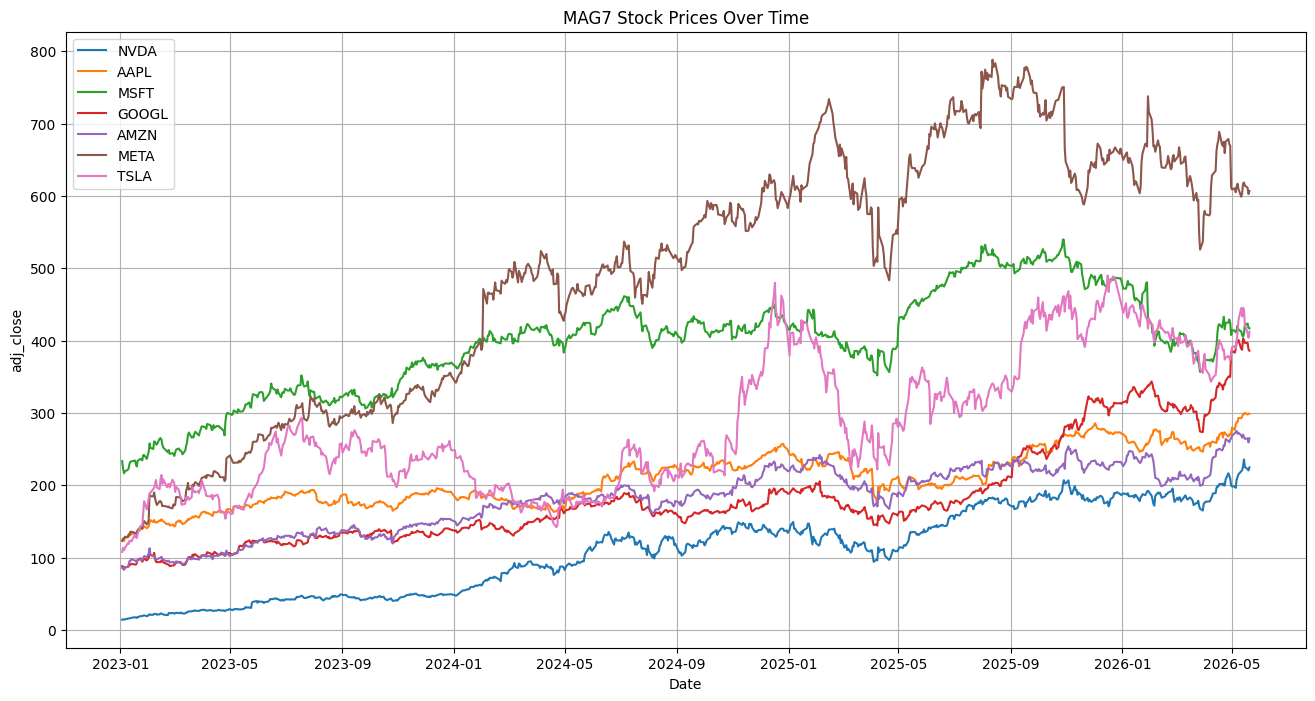

In [19]:
# Use adjusted close if available
price_col = "adj_close" if "adj_close" in prices_df.columns else "close"

plt.figure(figsize=(16, 8))

for ticker in prices_df["ticker"].unique():
    ticker_df = prices_df[prices_df["ticker"] == ticker]

    plt.plot(
        ticker_df["date"],
        ticker_df[price_col],
        label=ticker,
    )

plt.title("MAG7 Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel(price_col)
plt.legend()
plt.grid(True)

plt.show()

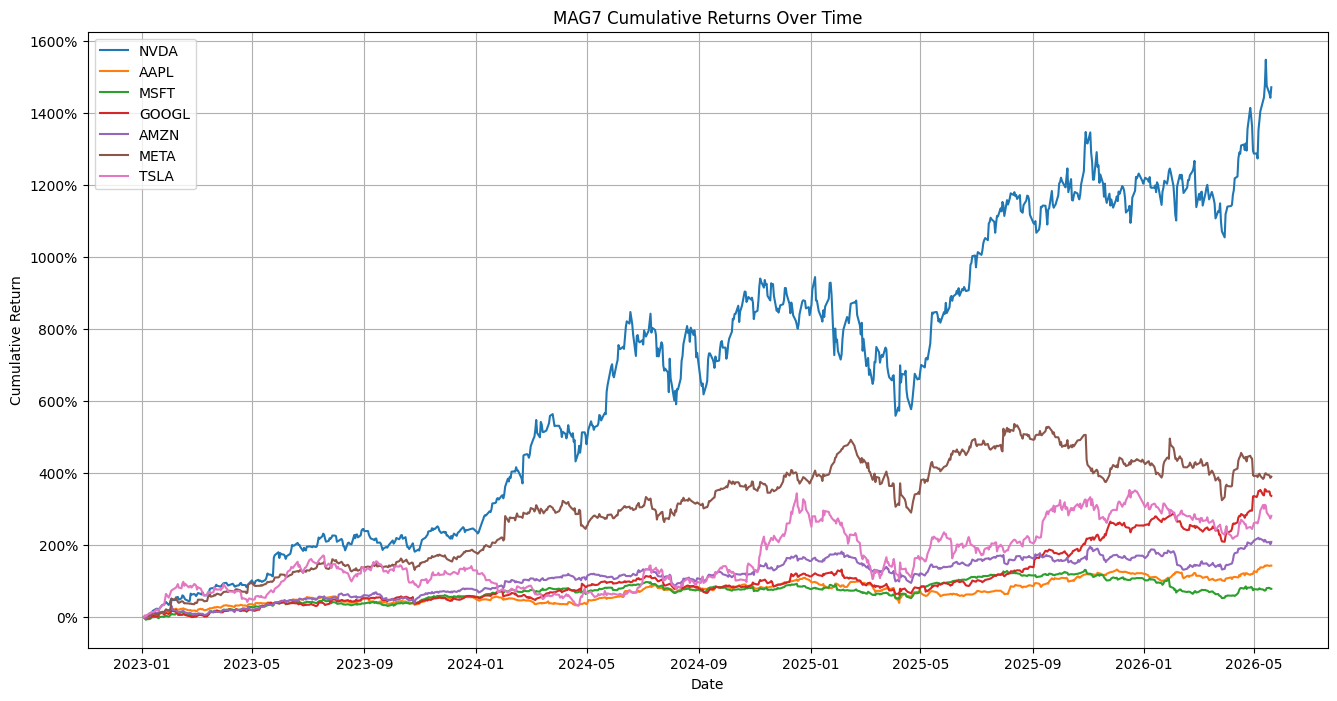

In [20]:
# Use adjusted close if available
price_col = "adj_close" if "adj_close" in prices_df.columns else "close"

plt.figure(figsize=(16, 8))

for ticker in prices_df["ticker"].unique():
    ticker_df = (
        prices_df[prices_df["ticker"] == ticker]
        .sort_values("date")
        .copy()
    )

    # Normalized cumulative return
    ticker_df["returns"] = (
        ticker_df[price_col] / ticker_df[price_col].iloc[0]
    ) - 1

    plt.plot(
        ticker_df["date"],
        ticker_df["returns"],
        label=ticker,
    )

plt.title("MAG7 Cumulative Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

# Format as percentages
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.legend()
plt.grid(True)

plt.show()

In [26]:
articles_df["month"].unique()

<ArrowStringArray>
['2025-09', '2024-03', '2023-07', '2023-03', '2024-07', '2023-05', '2024-02',
 '2024-08', '2026-02', '2025-05', '2025-02', '2024-09', '2023-10', '2025-01',
 '2024-12', '2023-02', '2025-03', '2024-11', '2023-04', '2025-08', '2025-11',
 '2024-01', '2024-10', '2023-12', '2023-06', '2023-11', '2026-01', '2023-09',
 '2024-06', '2025-12', '2026-04', '2024-05', '2025-04', '2023-08', '2024-04',
 '2026-03', '2025-06', '2025-07', '2023-01', '2025-10']
Length: 40, dtype: str